In [ ]:
%%capture
!pip install ffmpeg

In [ ]:
%%capture
!pip install cpnet

import cpnet

In [1]:
from google.colab import drive

import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, FFMpegWriter

import pickle

drive.mount("/content/drive")

Mounted at /content/drive


In [16]:
%cd /content/drive/MyDrive/Szakdoga/Codes
from graph_aggregator import SceneAggregator, create_graph ## The previous line is needed to find the graph.py file
from graph_visual import draw_graph, SceneVisualizer
from literature_objects import Segment # included here, because the pickled data uses Segment objects
%cd /content/drive/MyDrive/Szakdoga/Data

/content/drive/MyDrive/Szakdoga/Codes
/content/drive/MyDrive/Szakdoga/Data


## Creating a relationship graph

*p.s. a rajzolót lehet inkább egy Class-ba érdemes megírni, ha elegánsan akarom használni* - Done

In [14]:
#pickle.dump(test_data, open("HP2_by_chapter.p", "wb"))
test_data = pickle.load(open("HP1_by_chapter.p", "rb"))
is_directed = True

In [17]:
network_aggregated = SceneAggregator(nx.DiGraph if is_directed else nx.Graph)

for scene in test_data:
    G = create_graph(scene.network["characters"], nx.DiGraph() if is_directed else nx.Graph())
    network_aggregated.add_scene(G, scene)


#draw_graph(network, list(get_args(sentiments)))

# Visualizing the graph

##whole network

In [ ]:
network_aggregated.replay_evolution()

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
for i, _ in enumerate(test_data):
    network_aggregated.draw_scene(scene_index=i, min_connections=0, aggregate=False)


Output hidden; open in https://colab.research.google.com to view.

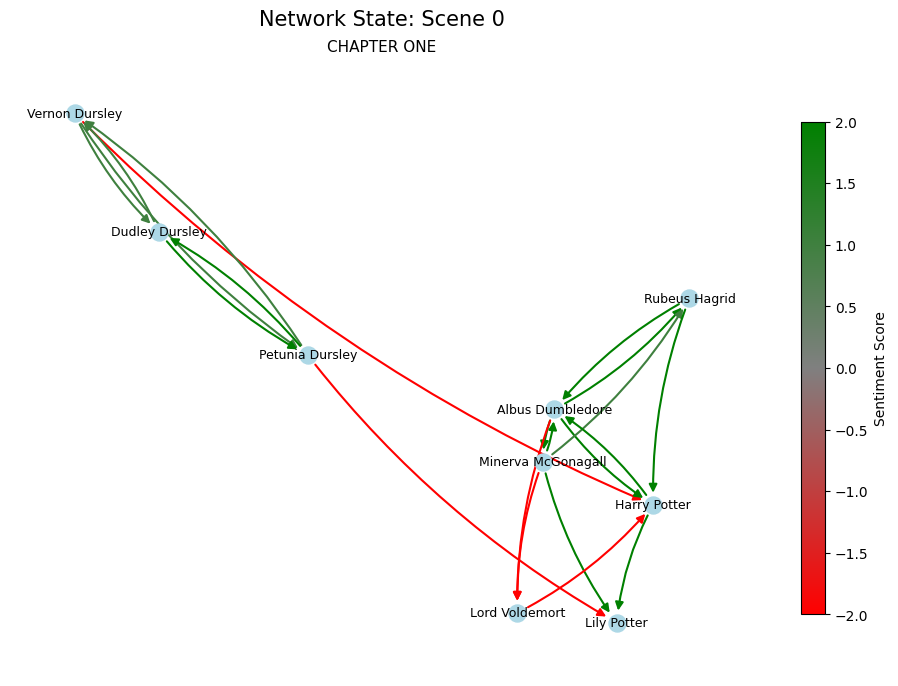

In [ ]:
animation: FuncAnimation = network_aggregated.create_animation(frame_length=2000, min_connections=3, aggregate=True)

In [ ]:
animation.save("../Visuals/Whole_book_test_by_chapter.mp4", writer="ffmpeg")

## Egocentric network

In [31]:
character = "Albus Dumbledore"
G = network_aggregated.get_network_at_scene(16).copy()

G_sub = nx.ego_graph(G, character, radius=1, undirected=True)

In [32]:
G = network_aggregated.get_network_at_scene(16).copy()

G.remove_nodes_from(["Harry Potter", "Ron Weasley", "Hermione Granger", "Draco"])

G = G.subgraph( max( nx.weakly_connected_components(G), key=lambda x: len(x))).copy()

G_sub = nx.ego_graph(G, character, radius=1, undirected=True)

#draw_graph(G_sub, labels=True, pos=nx.spring_layout(G_sub, scale = 3, seed=42), edge_args={"connectionstyle": "arc3, rad=0.0"}, node_args={"node_size": 150}, figsize=(16, 12))

In [33]:
dele = []
for e in G_sub.edges(data=True):
    if abs(e[2].get("sentiment", 0)) < 1:
        dele.append(e)

G_sub.remove_edges_from(dele)

In [34]:
for e in G_sub.edges(data=True):
    if e[2]["sentiment"] > 5:
        e[2]["sentiment"] = 5
    elif e[2]["sentiment"] < -5:
        e[2]["sentiment"] = -5

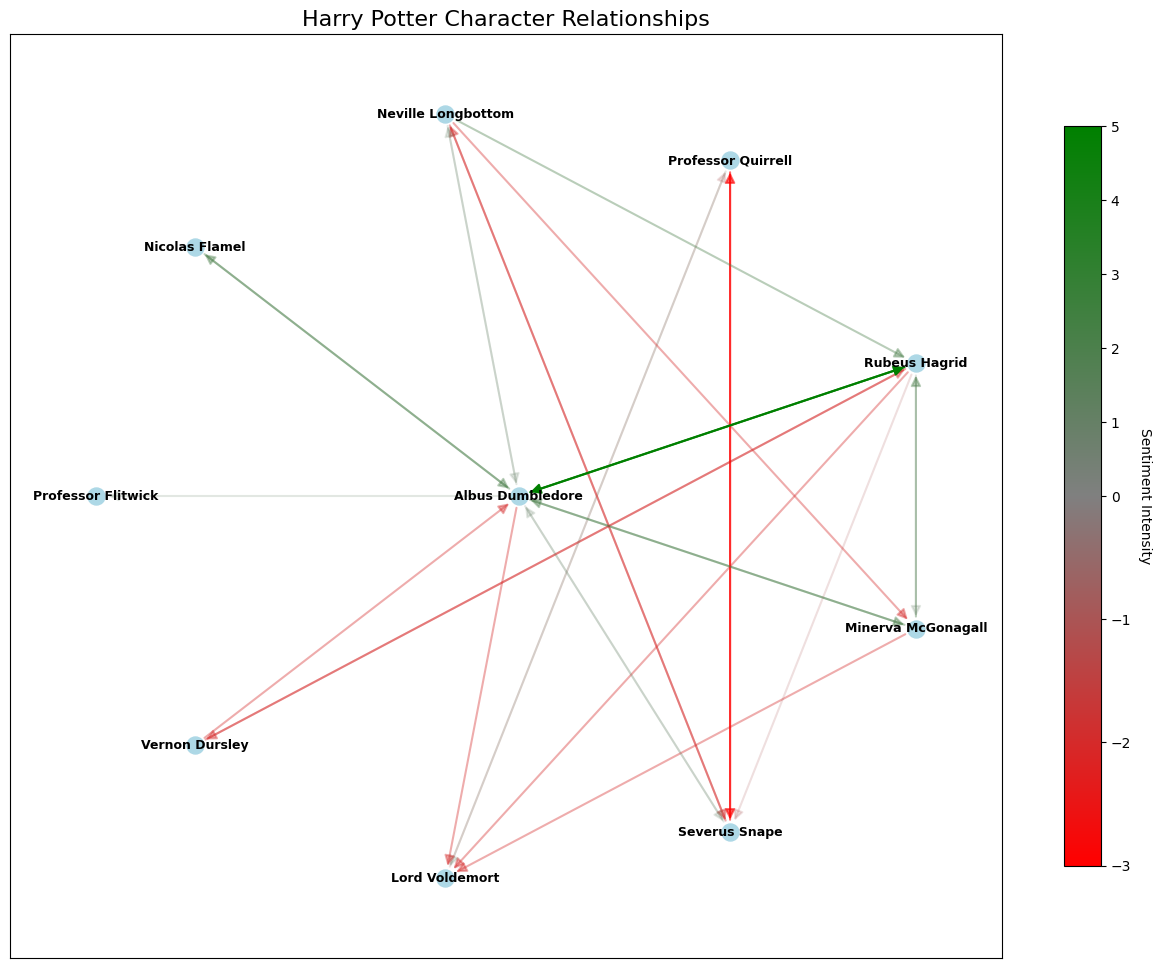

In [37]:
draw_graph(G_sub, labels=True, pos=nx.shell_layout(G_sub, [[character], list(G_sub.nodes() - {character})]),  edge_args={"connectionstyle": "arc3, rad=0.0"}, node_args={"node_size": 150}, figsize=(16, 12))

# Centrality measures

## Eigenvector centralities

In [ ]:
eigenvector_centralities_for_nodes = nx.eigenvector_centrality(network_aggregated.get_absolute_graph(16), weight="weight")

In [ ]:
max(eigenvector_centralities_for_nodes, key=lambda x: eigenvector_centralities_for_nodes[x])

'Harry Potter'

In [ ]:
sorted_eigenvector = sorted(eigenvector_centralities_for_nodes.items(), key=lambda x: x[1], reverse=True)
print("TOP 5:")
for char in sorted_eigenvector[:10]:
    print(char)
print("\nBottom 5:")

for char in sorted_eigenvector[-7:]:
    print(char)

TOP 5:
('Harry Potter', 0.6067641185524353)
('Ron Weasley', 0.38971508637727426)
('Rubeus Hagrid', 0.3647510749715914)
('Draco Malfoy', 0.3073584833429082)
('Hermione Granger', 0.2738424129509093)
('Severus Snape', 0.22973363427396057)
('Vernon Dursley', 0.15071715188243)
('Albus Dumbledore', 0.14681534583041386)
('Dudley Dursley', 0.11824280836682563)
('Petunia Dursley', 0.10875082920960238)

Bottom 5:
('Hotel Owner', 2.337942547408362e-49)
('Owl', 2.337942547408362e-49)
('Mr. Ollivander', 2.337942547408362e-49)
('Griphook', 2.337942547408362e-49)
('The Delivery Owl', 2.337942547408362e-49)
('Madam Malkin', 2.337942547408362e-49)
('The Stranger', 2.337942547408362e-49)


In [ ]:
# Dictionary structure: { 'NodeName': [val_scene0, val_scene1, ...] }
centrality_history = {node: [] for node in network_aggregated.get_network_at_scene(100).nodes()}

for i, _ in enumerate(network_aggregated.scenes):
    G_scene = network_aggregated.get_network_at_scene(i)

    centralities = nx.eigenvector_centrality(G_scene, max_iter=1000, weight='sentiment')

    for node in centrality_history:
        centrality_history[node].append(centralities.get(node, 0))

#get top nodes
final_scene_sorted = sorted(centralities.items(), key=lambda x: x[1], reverse=True)
top_nodes = [node for node, val in final_scene_sorted[:5]]
bottom_nodes = [node for node, val in final_scene_sorted[-5:]]

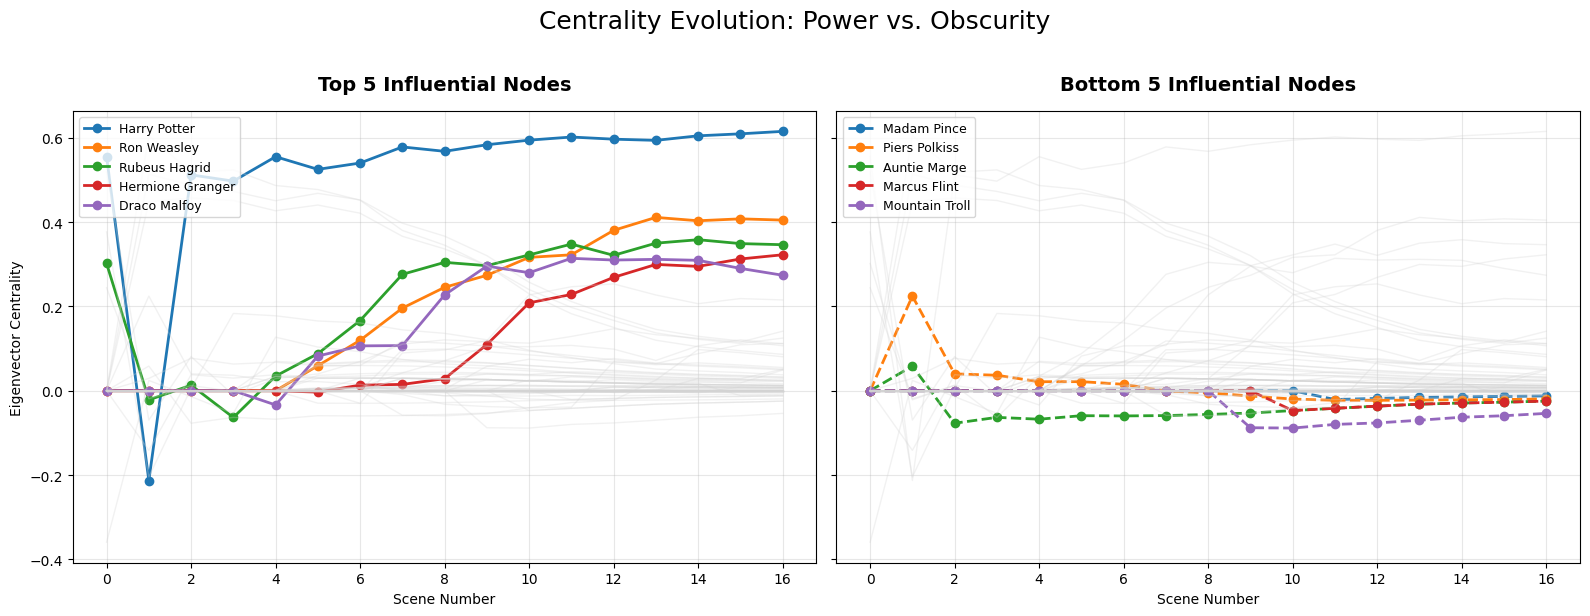

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# --- Subplot 1: TOP 5 ---
for node in top_nodes:
    ax1.plot(range(len(network_aggregated.scenes)), centrality_history[node], marker='o', label=node, linewidth=2)
ax1.set_title("Top 5 Influential Nodes", fontsize=14, fontweight='bold', pad=15)
ax1.set_ylabel("Eigenvector Centrality")
ax1.legend(loc='upper left', fontsize=9)
ax1.grid(True, alpha=0.3)

# --- Subplot 2: BOTTOM 5 ---
for node in bottom_nodes:
    ax2.plot(range(len(network_aggregated.scenes)), centrality_history[node], marker='o', linestyle='--', label=node, linewidth=2)
ax2.set_title("Bottom 5 Influential Nodes", fontsize=14, fontweight='bold', pad=15)
ax2.legend(loc='upper left', fontsize=9)
ax2.grid(True, alpha=0.3)

for node in centrality_history:
    if node not in top_nodes:
        ax1.plot(range(len(network_aggregated.scenes)), centrality_history[node], color='lightgrey', alpha=0.3, linewidth=1)
    if node not in bottom_nodes:
        ax2.plot(range(len(network_aggregated.scenes)), centrality_history[node], color='lightgrey', alpha=0.3, linewidth=1)

# Global formatting
fig.suptitle("Centrality Evolution: Power vs. Obscurity", fontsize=18, y=1.02)
for ax in [ax1, ax2]:
    ax.set_xlabel("Scene Number")

plt.tight_layout()
plt.show()

In [ ]:
network_aggregated.get_network_at_scene(3).edges(data=True)

OutEdgeDataView([('Vernon Dursley', 'Petunia Dursley', {'sentiment': 4}), ('Vernon Dursley', 'Harry Potter', {'sentiment': 8}), ('Vernon Dursley', 'Dudley Dursley', {'sentiment': 6}), ('Vernon Dursley', 'Dedalus Diggle', {'sentiment': 0}), ('Vernon Dursley', 'Rubeus Hagrid', {'sentiment': -2}), ('Vernon Dursley', 'Albus Dumbledore', {'sentiment': -2}), ('Petunia Dursley', 'Vernon Dursley', {'sentiment': 4}), ('Petunia Dursley', 'Dudley Dursley', {'sentiment': 6}), ('Petunia Dursley', 'Lily Potter', {'sentiment': 4}), ('Petunia Dursley', 'Harry Potter', {'sentiment': 5}), ('Dudley Dursley', 'Vernon Dursley', {'sentiment': 4}), ('Dudley Dursley', 'Petunia Dursley', {'sentiment': 6}), ('Dudley Dursley', 'Harry Potter', {'sentiment': 4}), ('Dudley Dursley', 'Piers Polkiss', {'sentiment': 3}), ('Dudley Dursley', 'Boa Constrictor', {'sentiment': -1}), ('Dudley Dursley', 'Rubeus Hagrid', {'sentiment': -2}), ('Albus Dumbledore', 'Minerva McGonagall', {'sentiment': 2}), ('Albus Dumbledore', 'Ru

## Betweenness centralities

In [ ]:
betweenness_centrality = nx.betweenness_centrality(network_aggregated.get_network_at_scene(16), weight="sentiment", seed=42)
sorted_betweenness = sorted(betweenness_centrality.items(), key=lambda x: x[1], reverse=True)

In [ ]:
for char in sorted_betweenness[:5]:
    print(char)
print("\nBottom 5:")

for char in sorted_betweenness[-5:]:
    print(char)

('Harry Potter', 8.906991336161504)
('Rubeus Hagrid', 3.9291416266025636)
('Draco Malfoy', 0.43681523041180337)
('Severus Snape', 0.40030013959983757)
('Neville Longbottom', 0.39849805626650425)

Bottom 5:
('Lee Jordan', 0.0)
('Madam Pince', 0.0)
('Perenelle Flamel', 0.0)
('Madam Pomfrey', 0.0)
('The Stranger', 0.0)


In [ ]:
# Dictionary structure: { 'NodeName': [val_scene0, val_scene1, ...] }
betweenness_history = {node: [] for node in network_aggregated.get_network_at_scene(100).nodes()}

for i, _ in enumerate(network_aggregated.scenes):
    G_scene = network_aggregated.get_network_at_scene(i)

    centralities = nx.betweenness_centrality(G_scene, weight='sentiment', seed=42)

    for node in betweenness_history:
        betweenness_history[node].append(centralities.get(node, 0))

#get top nodes
final_scene_sorted = sorted(centralities.items(), key=lambda x: x[1], reverse=True)
top_nodes = [node for node, val in final_scene_sorted[:5]]
bottom_nodes = [node for node, val in final_scene_sorted[-5:]]

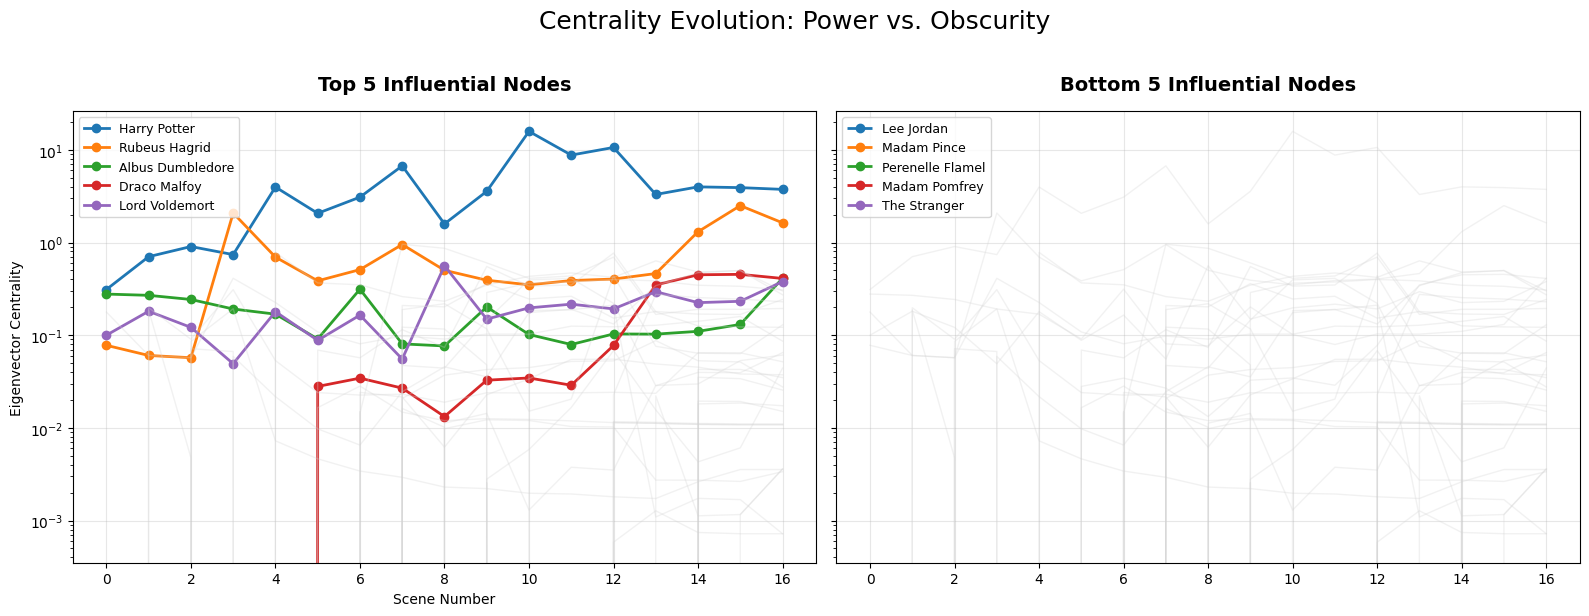

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# --- Subplot 1: TOP 5 ---
for node in top_nodes:
    ax1.plot(range(len(network_aggregated.scenes)), betweenness_history[node], marker='o', label=node, linewidth=2)
ax1.set_title("Top 5 Influential Nodes", fontsize=14, fontweight='bold', pad=15)
ax1.set_ylabel("Eigenvector Centrality")
ax1.legend(loc='upper left', fontsize=9)
ax1.grid(True, alpha=0.3)

# --- Subplot 2: BOTTOM 5 ---
for node in bottom_nodes:
    ax2.plot(range(len(network_aggregated.scenes)), betweenness_history[node], marker='o', linestyle='--', label=node, linewidth=2)
ax2.set_title("Bottom 5 Influential Nodes", fontsize=14, fontweight='bold', pad=15)
ax2.legend(loc='upper left', fontsize=9)
ax2.grid(True, alpha=0.3)

for node in betweenness_history:
    if node not in top_nodes:
        ax1.plot(range(len(network_aggregated.scenes)), betweenness_history[node], color='lightgrey', alpha=0.3, linewidth=1)
    if node not in bottom_nodes:
        ax2.plot(range(len(network_aggregated.scenes)), betweenness_history[node], color='lightgrey', alpha=0.3, linewidth=1)

# Global formatting
fig.suptitle("Centrality Evolution: Power vs. Obscurity", fontsize=18, y=1.02)
for ax in [ax1, ax2]:
    ax1.set_xlabel("Scene Number")

ax.set_yscale("log")

plt.tight_layout()
plt.show()

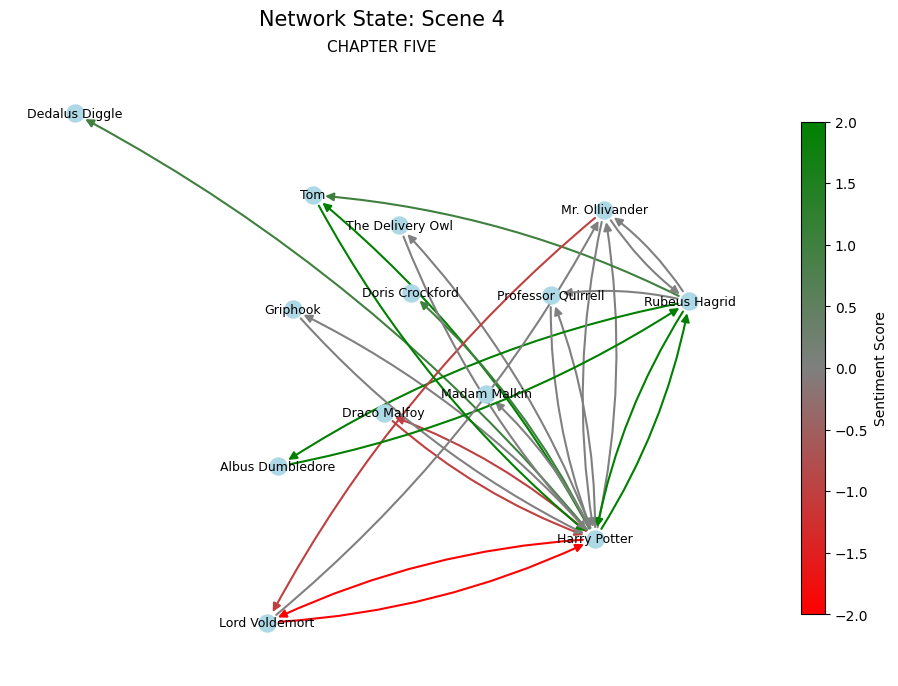

In [ ]:
network_aggregated.draw_scene(4)

# Community detection

## NetworkX version

In [ ]:
communities_asyn_lpa = nx.community.asyn_lpa_communities(network_aggregated.get_network_at_scene(16), weight="sentiment", seed=42)
for c in communities_asyn_lpa:
    print(c)

{'Petunia Dursley', 'Dudley Dursley', 'Piers Polkiss', 'Vernon Dursley'}
{'Ron Weasley', 'Tom', 'Neville Longbottom', 'The Stranger', 'Griphook', 'Professor Flitwick', 'Firenze', 'Peeves', 'Nearly Headless Nick', 'Marcus Flint', 'Boa Constrictor', 'Rubeus Hagrid', 'Nicolas Flamel', 'Mrs. Figg', 'Percy Weasley', 'Oliver Wood', 'Albus Dumbledore', 'Hermione Granger', 'Harry Potter', 'Mountain Troll', 'Mrs. Weasley', 'Fang', 'The Delivery Owl', 'Hotel Owner', 'Auntie Marge', 'Mr. Ollivander', 'Norbert', 'Fluffy', 'The Sorting Hat', 'Owl', 'Seamus Finnigan', 'Madam Pomfrey'}
{'Minerva McGonagall', 'Lee Jordan', 'Lily Potter'}
{'Professor Quirrell', 'Lord Voldemort'}
{'Dedalus Diggle'}
{'Sirius Black'}
{'Draco Malfoy', 'Severus Snape'}
{'Doris Crockford'}
{'Madam Malkin'}
{'Scabbers', 'Goyle'}
{'Hedwig'}
{'The Guard'}
{'Fred Weasley'}
{'George Weasley'}
{'Ginny Weasley'}
{'Crabbe'}
{'Great Uncle Algie'}
{'Mrs. Norris', 'Argus Filch'}
{'Parvati Patil', 'Pansy Parkinson'}
{'Dean Thomas'}
{'Ma

In [ ]:
communities_asyn_lpa_abs = nx.community.asyn_lpa_communities(network_aggregated.get_absolute_graph(scene_index=16), weight="weight", seed=42)
for c in communities_asyn_lpa_abs:
    print(c)

{'Ron Weasley', 'Argus Filch', 'Vernon Dursley', 'Petunia Dursley', 'Dudley Dursley', 'Tom', 'Neville Longbottom', 'The Stranger', 'Griphook', 'Lee Jordan', 'Professor Flitwick', 'Peeves', 'Nearly Headless Nick', 'Marcus Flint', 'Boa Constrictor', 'Rubeus Hagrid', 'Mrs. Norris', 'Lord Voldemort', 'Nicolas Flamel', 'Mrs. Figg', 'Percy Weasley', 'Professor Quirrell', 'Albus Dumbledore', 'Hermione Granger', 'Harry Potter', 'Oliver Wood', 'Severus Snape', 'Mrs. Weasley', 'Mountain Troll', 'Fang', 'The Delivery Owl', 'Minerva McGonagall', 'Hotel Owner', 'Piers Polkiss', 'Draco Malfoy', 'Auntie Marge', 'Mr. Ollivander', 'Norbert', 'Fluffy', 'The Sorting Hat', 'Owl', 'Seamus Finnigan', 'Madam Pomfrey'}
{'Dedalus Diggle'}
{'Lily Potter'}
{'Sirius Black'}
{'Doris Crockford'}
{'Madam Malkin'}
{'Scabbers', 'Goyle'}
{'Hedwig'}
{'The Guard'}
{'Fred Weasley'}
{'George Weasley'}
{'Ginny Weasley'}
{'Crabbe'}
{'Great Uncle Algie'}
{'Parvati Patil', 'Pansy Parkinson'}
{'Dean Thomas'}
{'Madam Hooch'}
{'M

In [ ]:
G = network_aggregated.get_network_at_scene(16).copy()
edges_to_remove = []

for edge in G.edges(data=True):
    if edge[2].get("sentiment", 0) < 0:
        edges_to_remove.append(edge)

G.remove_edges_from(edges_to_remove)

communities_asyn_lpa_negative_cut = nx.community.asyn_lpa_communities(G, weight="sentiment", seed=42)
for c in communities_asyn_lpa_negative_cut:
    print(c)

{'Petunia Dursley', 'Dudley Dursley', 'Piers Polkiss', 'Vernon Dursley'}
{'Ron Weasley', 'Tom', 'Neville Longbottom', 'The Stranger', 'Griphook', 'Professor Flitwick', 'Firenze', 'Peeves', 'Nearly Headless Nick', 'Boa Constrictor', 'Rubeus Hagrid', 'Lord Voldemort', 'Nicolas Flamel', 'Mrs. Figg', 'Percy Weasley', 'Professor Quirrell', 'Albus Dumbledore', 'Hermione Granger', 'Harry Potter', 'Oliver Wood', 'Mrs. Weasley', 'Fang', 'The Delivery Owl', 'Minerva McGonagall', 'Hotel Owner', 'Mr. Ollivander', 'Norbert', 'Fluffy', 'The Sorting Hat', 'Owl', 'Seamus Finnigan', 'Madam Pomfrey'}
{'Dedalus Diggle'}
{'Lily Potter'}
{'Sirius Black'}
{'Auntie Marge'}
{'Crabbe', 'Draco Malfoy', 'Severus Snape'}
{'Doris Crockford'}
{'Madam Malkin'}
{'Scabbers'}
{'Hedwig'}
{'The Guard'}
{'Fred Weasley'}
{'George Weasley'}
{'Ginny Weasley'}
{'Goyle'}
{'Great Uncle Algie'}
{'Mrs. Norris', 'Argus Filch'}
{'Parvati Patil'}
{'Dean Thomas'}
{'Madam Hooch'}
{'Pansy Parkinson'}
{'Mountain Troll'}
{'Marcus Flint'}

In [ ]:
communities_fast_lpa_abs = nx.community.fast_label_propagation_communities(network_aggregated.get_absolute_graph(scene_index=16), weight="weight", seed=42)
for c in communities_fast_lpa_abs:
    print(c)

{'Justin Finch-Fletchley', 'Fang', 'Neville Longbottom', 'Gilderoy Lockhart', 'Draco Malfoy', 'Lucius Malfoy', 'Professor Sprout', 'Sorting Hat', 'Rubeus Hagrid', 'Lord Voldemort', 'Albus Dumbledore', 'Petunia Dursley', 'George Weasley', 'Errol', 'Vernon Dursley', 'Mr. Borgin', 'Ginny Weasley', 'Severus Snape', 'Seamus Finnigan', 'Fawkes', 'Basilisk', 'Moaning Myrtle', 'Dobby', 'Colin Creevey', 'Penelope Clearwater', 'Oliver Wood', 'Professor Dippet', 'Ernie Macmillan', 'Hedwig', 'Percy Weasley', 'Madam Pince', 'Dudley Dursley', 'Professor Binns', 'Madam Pomfrey', 'Mr. Granger', 'Sir Patrick Delaney-Podmore', "Mr. Weasley's Car", 'Ron Weasley', 'Cornelius Fudge', 'Aragog', 'The Snake', 'Fred Weasley', 'Nearly Headless Nick', 'Hermione Granger', 'Arthur Weasley', 'Argus Filch', 'Peeves', 'Harry Potter', 'Minerva McGonagall', 'Molly Weasley', 'Mrs. Norris', 'Mafalda Hopkirk', 'Hannah Abbott', 'Mr. Mason', 'Millicent Bulstrode', 'Marcus Flint', 'Whomping Willow'}
{'Barn Owl', 'Mrs. Mason'

In [ ]:
communities_louvain = nx.community.louvain_communities(network_aggregated.get_network_at_scene(16), weight="sentiment", seed=42)
for c in communities_louvain:
    print(c)

{'Petunia Dursley', 'Mr. Mason', 'Mrs. Mason', 'Dudley Dursley', 'Vernon Dursley'}
{'Professor Dippet', 'Hedwig', 'Neville Longbottom', "Mr. Weasley's Car", 'Lucius Malfoy', 'Ron Weasley', 'Cornelius Fudge', 'The Snake', 'Nearly Headless Nick', 'Fred Weasley', 'Lord Voldemort', 'George Weasley', 'Peeves', 'Harry Potter', 'Mr. Borgin', 'Basilisk', 'Moaning Myrtle', 'Colin Creevey', 'Oliver Wood'}
{'Rubeus Hagrid', 'Errol', 'Hermione Granger', 'Madam Pince', 'Fang', 'Aragog', 'Gilderoy Lockhart', 'Draco Malfoy', 'Marcus Flint', 'Professor Sprout'}
{'Mafalda Hopkirk'}
{'Barn Owl'}
{'Seamus Finnigan'}
{'Sir Patrick Delaney-Podmore'}
{'Albus Dumbledore', 'Argus Filch', 'Arthur Weasley', 'Minerva McGonagall', 'Percy Weasley', 'Molly Weasley', 'Severus Snape', 'Mrs. Norris', 'Ginny Weasley', 'Fawkes', 'Madam Pomfrey', 'Mr. Granger', 'Dobby', 'Penelope Clearwater', 'Whomping Willow'}
{'Professor Binns'}
{'Justin Finch-Fletchley', 'Ernie Macmillan', 'Hannah Abbott'}
{'Millicent Bulstrode'}
{'So

In [ ]:
communities_louvain_abs = nx.community.louvain_communities(network_aggregated.get_absolute_graph(16), weight="weight", seed=42)
for c in communities_louvain_abs:
    print(c)

{'Hedwig', 'Percy Weasley', 'Madam Pince', 'Neville Longbottom', "Mr. Weasley's Car", 'Draco Malfoy', 'Ron Weasley', 'The Snake', 'Fred Weasley', 'George Weasley', 'Harry Potter', 'Molly Weasley', 'Mafalda Hopkirk', 'Ginny Weasley', 'Oliver Wood', 'Colin Creevey', 'Penelope Clearwater', 'Marcus Flint', 'Whomping Willow'}
{'Errol', 'Hermione Granger', 'Gilderoy Lockhart', 'Moaning Myrtle', 'Severus Snape', 'Millicent Bulstrode', 'Professor Sprout'}
{'Barn Owl', 'Petunia Dursley', 'Mr. Mason', 'Mrs. Mason', 'Dudley Dursley', 'Vernon Dursley'}
{'Fang', 'Madam Pomfrey', 'Mr. Granger', 'Lucius Malfoy', 'Cornelius Fudge', 'Aragog', 'Rubeus Hagrid', 'Albus Dumbledore', 'Lord Voldemort', 'Arthur Weasley', 'Minerva McGonagall', 'Seamus Finnigan', 'Mr. Borgin', 'Fawkes', 'Basilisk', 'Dobby', 'Professor Dippet'}
{'Mrs. Norris', 'Nearly Headless Nick', 'Argus Filch', 'Peeves', 'Sir Patrick Delaney-Podmore'}
{'Professor Binns'}
{'Justin Finch-Fletchley', 'Ernie Macmillan', 'Hannah Abbott'}
{'Sortin

## Core-periphery detection
*with cpnet*

In [ ]:
algorithm = cpnet.LowRankCore()

In [ ]:
G = network_aggregated.get_network_at_scene(16).copy()
algorithm.detect(G)

In [ ]:
#c = algorithm.get_pair_id()
x = algorithm.get_coreness()

core = [node for node in G.nodes() if x[node] == 1]
periphery = [node for node in G.nodes() if x[node] == 0]

In [ ]:
edges_to_delete = []

for e in G.edges:
    if e[0] in core and e[1] in core:
        edges_to_delete.append(e)

G.remove_edges_from(edges_to_delete)

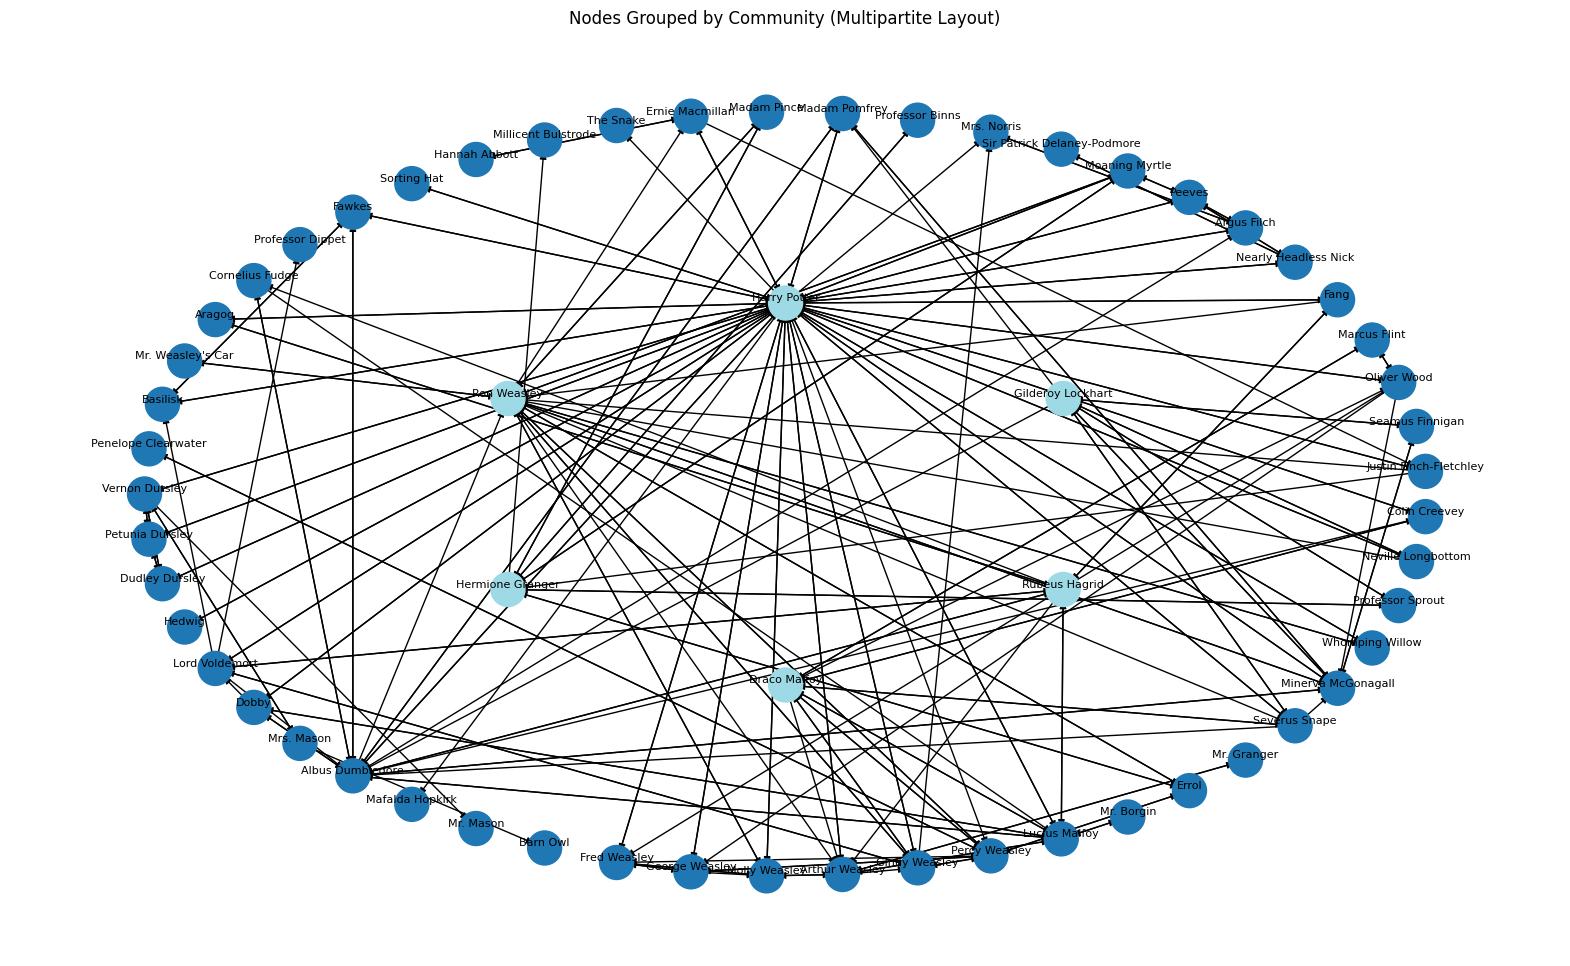

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx

# Create the subset mapping required for multipartite_layout
# c is already a dictionary mapping node -> group_id
# We ensure the values are hashable (integers)
subset_map = {node: int(x.get(node, 0)) for node in G.nodes()}

# Set the subset mapping as a node attribute
nx.set_node_attributes(G, subset_map, 'community')

# Use multipartite_layout with the attribute name
pos = nx.shell_layout(G, [core, periphery])

plt.figure(figsize=(20, 12))

# Map groups in 'c' to colors
node_colors = [x.get(node, 0) for node in G.nodes()]

# Draw nodes and labels
nx.draw_networkx_nodes(G, pos, node_color=node_colors, cmap=plt.cm.tab20, node_size=600)
nx.draw_networkx_edges(G, pos)
nx.draw_networkx_labels(G, pos, font_size=8, verticalalignment='bottom')

plt.title("Nodes Grouped by Community (Multipartite Layout)")
plt.axis("off")
plt.show()

## Java version

*discontinued - nem akart működni és így nem éri meg folytatni*

In [ ]:
# Creation of text file

node_label_map = {}
t = 0

with open("../Data/java_text_input_hp1.txt", "w") as ff:
    for edge in network_aggregated.get_network_at_scene(16).edges(data=True):
        if edge[0] not in node_label_map:
            node_label_map[edge[0]] = t
            t += 1
        if edge[1] not in node_label_map:
            node_label_map[edge[1]] = t
            t += 1


        ff.write(f"""{node_label_map[edge[0]]} {node_label_map[edge[1]]} {edge[2].get("sentiment", 0)}\n""")

In [ ]:
%cd src/main/java/network/cli

/content/drive/MyDrive/Szakdoga/Codes/signed-community-detection/src/main/java/network/cli


In [ ]:
!mdl -h

/bin/bash: line 1: mdl: command not found


# Node/edge similarity

In [ ]:
#G = network_aggregated.get_network_at_scene(16).copy()

simrank_scores = nx.simrank_similarity(G, max_iterations=1000, tolerance=0.0001)
sim_arr = np.array([[simrank_scores[u][v] for v in G] for u in G])
sim_df = pd.DataFrame(sim_arr, index=G.nodes(), columns=G.nodes())

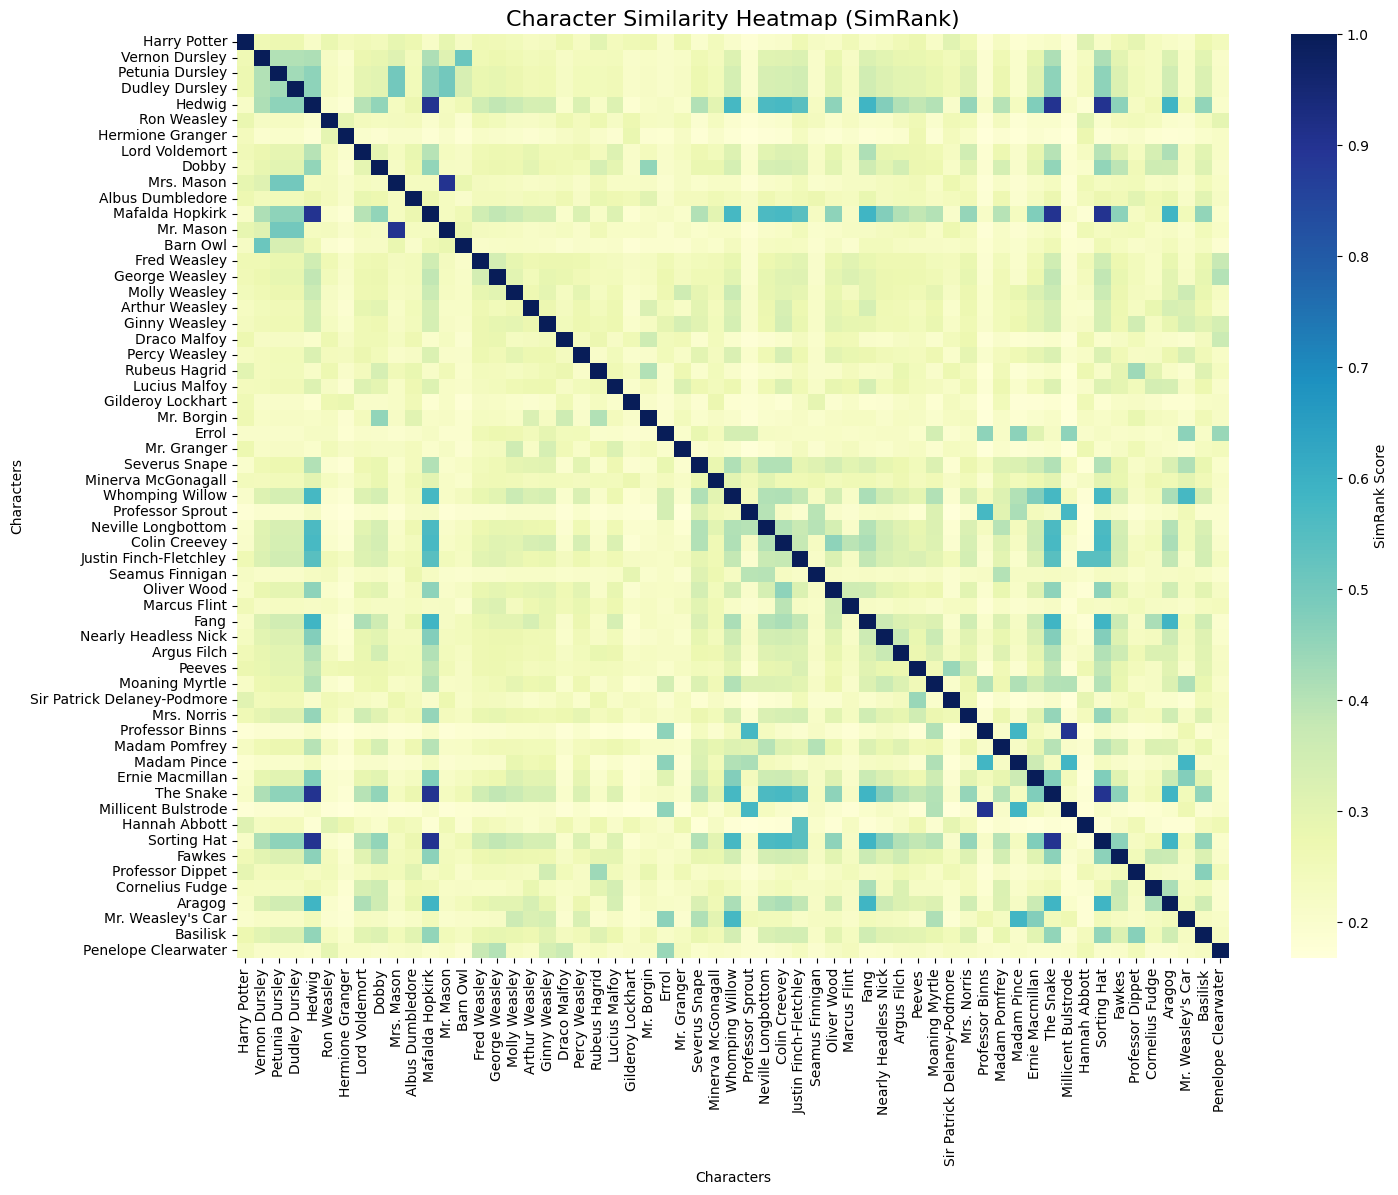

In [ ]:
import seaborn as sns
from sklearn.cluster import KMeans

# Set up the matplotlib figure
plt.figure(figsize=(16, 12))

# Draw the heatmap
sns.heatmap(sim_df, annot=False, cmap="YlGnBu", cbar_kws={'label': 'SimRank Score'})

plt.title("Character Similarity Heatmap (SimRank)", fontsize=16)
plt.xlabel("Characters")
plt.ylabel("Characters")
plt.show()

In [ ]:
n_communities = 6  # You can use the elbow method to find the optimal number
kmeans = KMeans(n_clusters=n_communities, random_state=42).fit(sim_arr)
community_map = dict(zip(G.nodes(), kmeans.labels_))

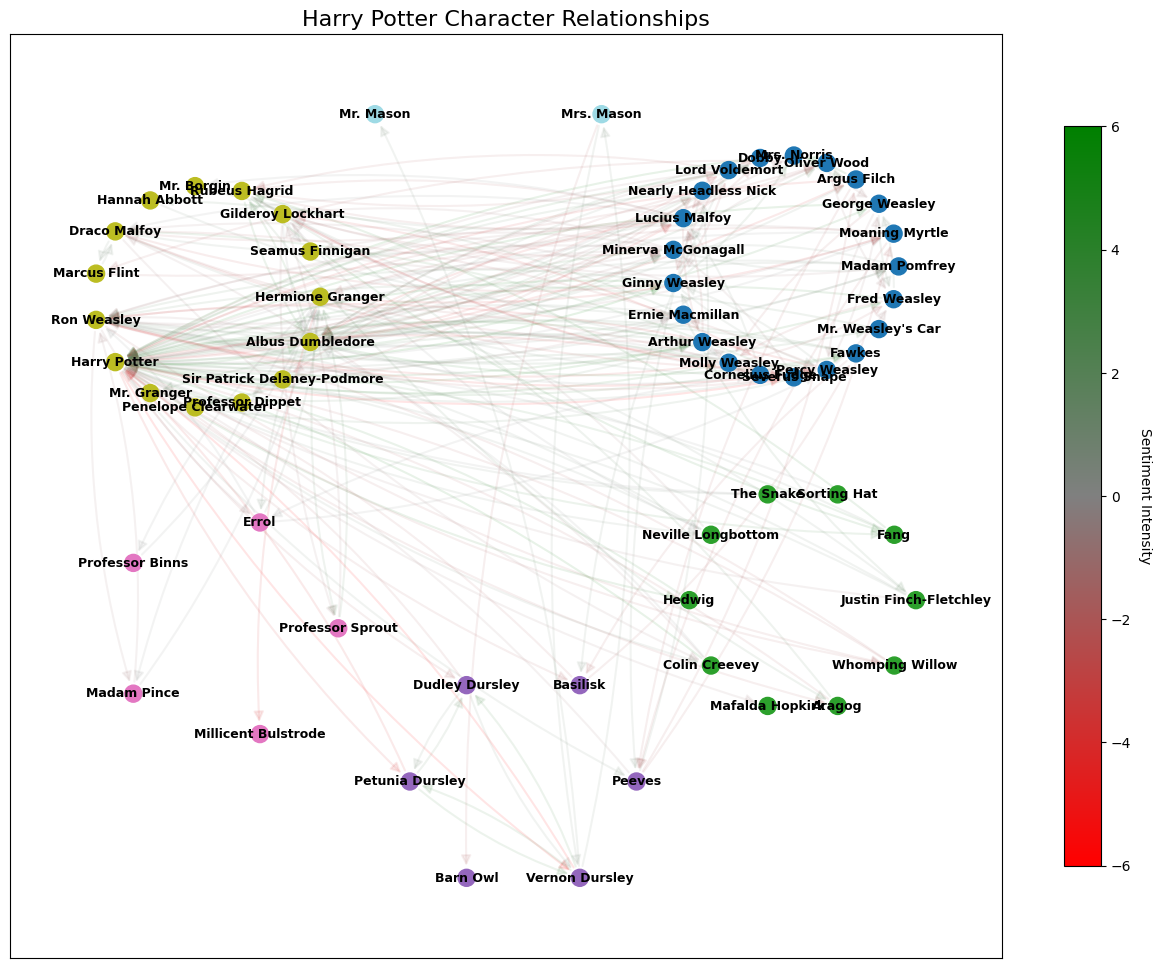

<Figure size 640x480 with 0 Axes>

In [ ]:
#communities = nx.community.greedy_modularity_communities(G)
communities = [set([node for node in G.nodes() if community_map[node] == i]) for i in range(n_communities)]
# Compute positions for the node clusters as if they were themselves nodes in a
# supergraph using a larger scale factor
supergraph = nx.cycle_graph(len(communities))
superpos = nx.spring_layout(supergraph, scale=3, seed=42)

# Use the "supernode" positions as the center of each node cluster
centers = list(superpos.values())
pos = {}
for center, comm in zip(centers, communities):
    pos.update(nx.circular_layout(nx.subgraph(G, comm), center=center))

node_colors = [community_map[n] for n in G.nodes()]

draw_graph(G, pos=pos, labels=True, figsize=(16, 12), alpha_min=0.1, alpha_max=0.11, node_args={"node_size": 150, "node_color": node_colors, "cmap": plt.cm.tab20})
#

plt.tight_layout()
plt.show()

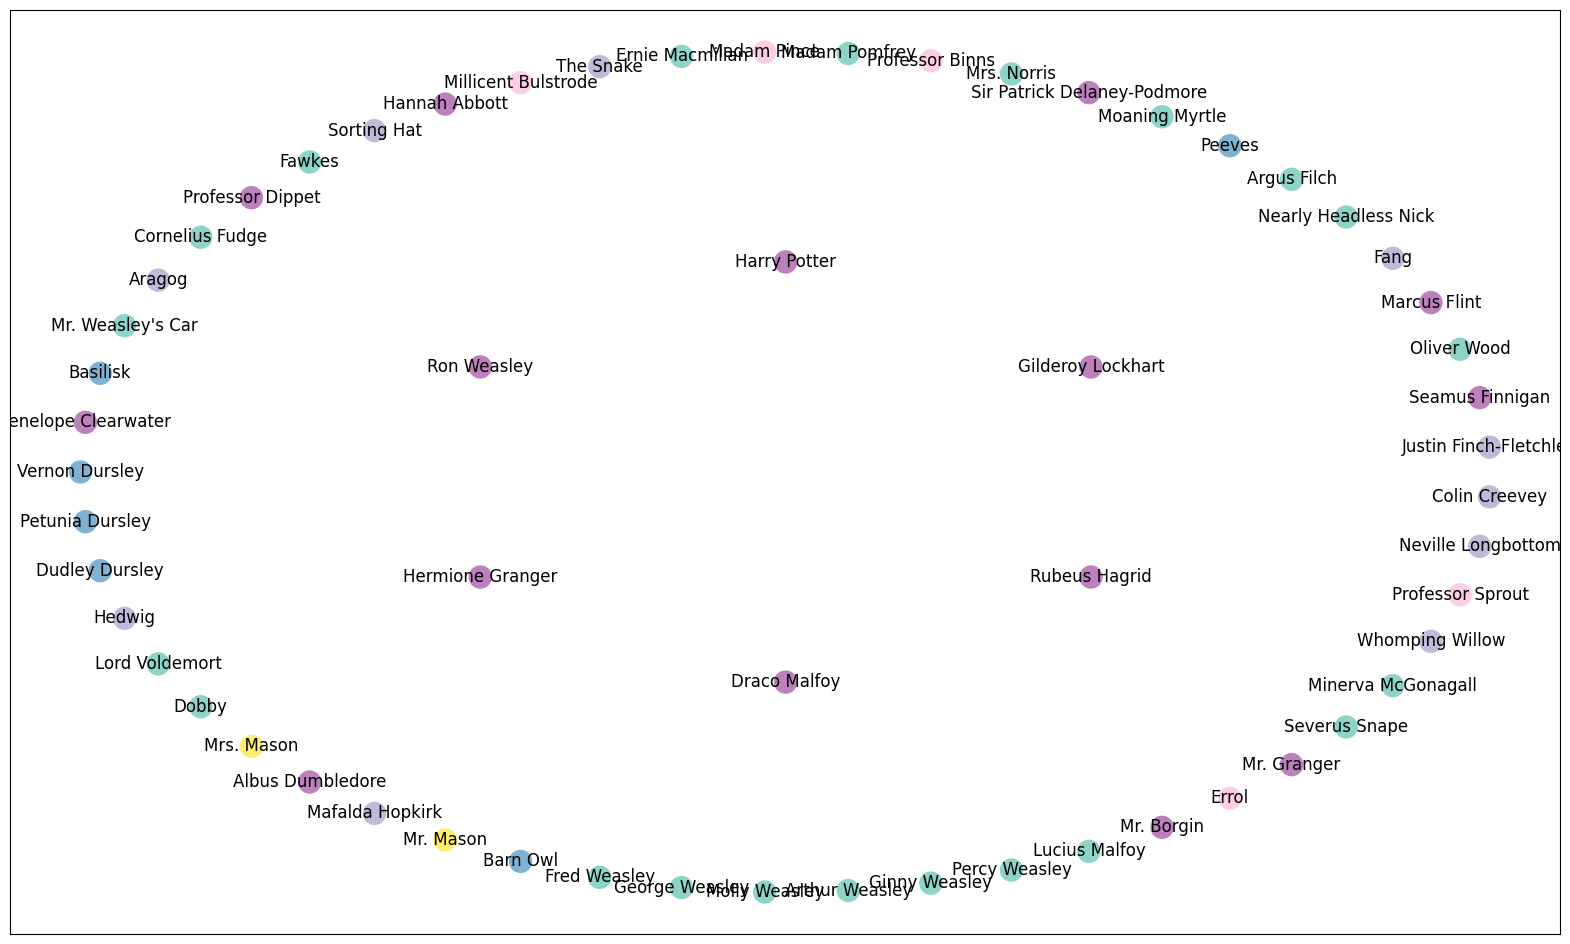

In [ ]:
node_colors = [community_map[n] for n in G.nodes()]
pos = nx.shell_layout(G, [core, periphery])

plt.figure(figsize=(20, 12))

# Draw the nodes with community coloring
nx.draw_networkx_nodes(
    G, pos,
    node_color=node_colors,
    cmap=plt.cm.Set3,  # Discrete colors for communities
    node_size=250
)

#nx.draw_networkx_edges(G, pos)
nx.draw_networkx_labels(G, pos)
print()

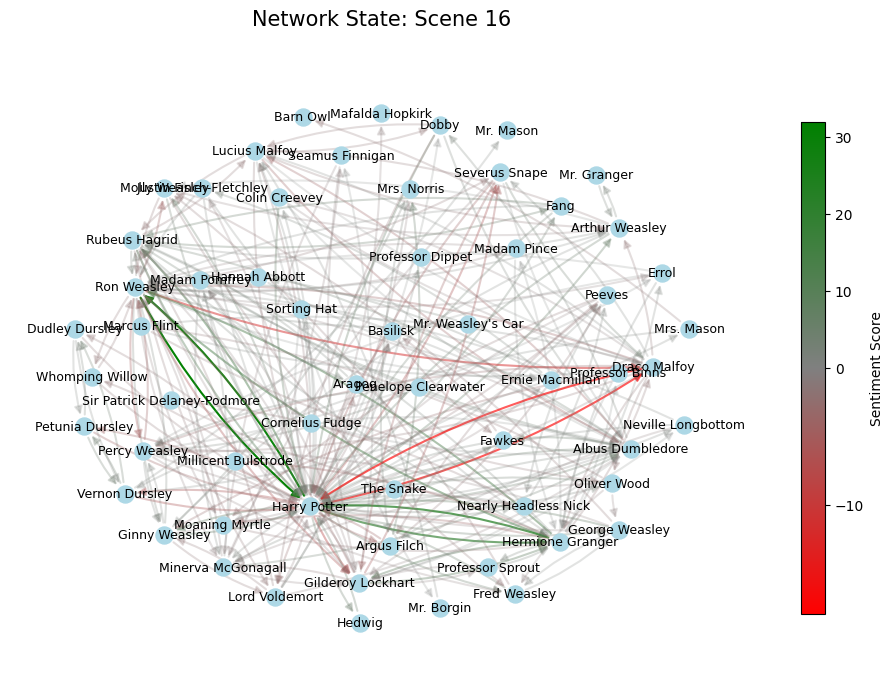

In [ ]:
network_aggregated.draw_scene(16, aggregate=True)

# Notes

# Szakdoga jegyzetek

## Abrazoals

- abrazolas rendberakni
	- undirected
	- színezve (bejovo elek sum előjele)
	-
- aggregalt / nemaggregalt halozat kirakva mappaba
- páros gráfként -> leszedve a kis foszámú éleket)


## Elamzes
- frusztraltság (olyan kör, amiben páratlan sok negatív él van)
	- eloszor haromszogeket -> kidobni
	- jelenetenkent és aggregáltra is.
	- ha ilyen nincs sok -> bipartite graph

- core kivesz, maradékra louveain com det
	- ha szétesik, community detection a connectedre (ha elég nagy $\geq$ 10 pl)


## To do list
---
*   Valahogy regularizálni kell a karakter neveket. Mégjobb ha ez automatikusan meg lehet csinálni. -> erre is el lehet lőni egy geminit, ismeri az eddigi - done karakterlistát, és használja azt a nevet, amin először megjelent a karakter. - Done
---
Ezek semmisnekk vannak tekintve:

*   Letesztelni, hogyan viselkedik hosszabb szekciókra a relációgráf kreálás. - véleményesen, az a vége, hogy fejezetenként kapja meg a könyvet, nem darabolunk
*   Tesztelni, mennyire konzisztens a darabolás, lehet-e benne bízni rendesen. - problematikus, és nehéz debugolni



## Wrap
---
*   Whole book cinema + aggregated network - Done
*   nx centrality options -> core-periphery, eigenvector etc.
*   Chapter by chapter network - done
*   Weight the connections with llm, -> how to prompt it?
*   tagged png for the network graphs - done

## Érdekes kérdések a következő hétre:
---



*   Milyen sentimenteket érdemes nézni, mennyire hajlamos a gemini "végletes" értékelésre.
*   Különbözik-e eredményt tekintve a pro és a flash modell?
*   Hogyan érdemes kiértékelni a feladat sikerességét, mivel lehet egyáltalán mérni, mennyire jók a sentimentek az *olvastam a fejezetet* módszeren kívül?
*   Érdemes e tényleg jelenetenként menni, mi történik ha fejezetenként, és mi ha bekezdésenként megyünk?
*   Directed vs undirected gráf? (egyáltalán van e különbség)
*   Lehet-e e nem gemini modellel, akár self host, akár nem neur hálós techinkával, végezni a darabolást?
*   Van-e érdemi különbség a jelenlegi elérhető LLM modellek (Gemini, GPT, Llama, Anthropic) között erre a feladatra?

